# Hard coal NPV simulation

Run the hard coal electricity Monte Carlo simulation and visualize the resulting NPV distribution.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from electricity.electricity_npv_monte_carlo import (
    DEFAULT_RANDOM_SEED,
    DEFAULT_SAMPLE_SIZE,
    simulate_hard_coal_npv,
)


In [2]:
SAMPLE_SIZE = DEFAULT_SAMPLE_SIZE
RANDOM_SEED = DEFAULT_RANDOM_SEED

rng = np.random.default_rng(RANDOM_SEED)
simulation = simulate_hard_coal_npv(size=SAMPLE_SIZE, rng=rng)
results = pd.DataFrame(simulation)

results.head()


,run_id,technology,annual_output_mwh,full_load_hours_per_year,capacity_mw,capacity_kw,capex_eur_per_kw,fixed_opex_eur_per_kw_year,variable_opex_eur_per_mwh,fuel_consumption_mwh_th_per_mwh_e,...,annual_revenue_eur,annual_fixed_opex_eur,annual_variable_opex_eur,annual_fuel_cost_eur,annual_emissions_cost_eur,annual_net_cash_flow_eur,npv_eur,lifetime_output_mwh,npv_eur_per_mwh,npv_million_eur_per_mwh
0,0,hard_coal,1000000.0,4100.0,243.902439,243902.439024,2164.373629,44.557066,5.004625,2.562332,...,94070000.0,1.086758e+07,5.004625e+06,3.479139e+07,6.943458e+07,-2.602817e+07,-8.057409e+08,25000000.0,-32.229635,-0.000032
1,1,hard_coal,1000000.0,4100.0,243.902439,243902.439024,1963.327064,44.820402,4.989683,2.553297,...,94070000.0,1.093181e+07,4.989683e+06,2.331802e+07,7.182323e+07,-1.699274e+07,-6.602539e+08,25000000.0,-26.410157,-0.000026
2,2,hard_coal,1000000.0,4100.0,243.902439,243902.439024,2215.158752,38.338802,5.796462,2.607836,...,94070000.0,9.350927e+06,5.796462e+06,3.122638e+07,6.975697e+07,-2.206073e+07,-7.757760e+08,25000000.0,-31.031040,-0.000031
3,3,hard_coal,1000000.0,4100.0,243.902439,243902.439024,2118.420817,35.460324,5.241452,2.602842,...,94070000.0,8.648860e+06,5.241452e+06,2.858488e+07,7.079300e+07,-1.919819e+07,-7.216244e+08,25000000.0,-28.864975,-0.000029
4,4,hard_coal,1000000.0,4100.0,243.902439,243902.439024,1756.506409,40.783580,5.551210,2.604380,...,94070000.0,9.947215e+06,5.551210e+06,2.968629e+07,6.942755e+07,-2.054227e+07,-6.477003e+08,25000000.0,-25.908012,-0.000026


In [3]:
npv_million_eur = results["npv_eur"] / 1_000_000
npv_eur_per_mwh = results["npv_eur_per_mwh"]
summary = pd.concat(
    [
        npv_million_eur.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV million EUR"
        ),
        npv_eur_per_mwh.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV EUR/MWh"
        ),
    ],
    axis=1,
)
summary


,NPV million EUR,NPV EUR/MWh
count,100000.000000,100000.000000
mean,-715.788594,-28.631544
std,78.669564,3.146783
min,-1061.082322,-42.443293
5%,-855.005446,-34.200218
50%,-710.229584,-28.409183
95%,-595.054925,-23.802197
max,-500.253415,-20.010137


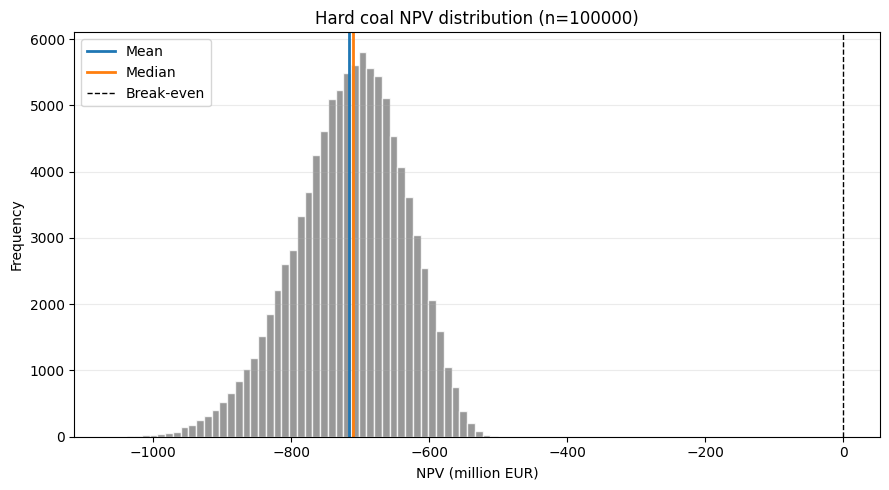

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(npv_million_eur, bins=50, color="tab:gray", edgecolor="white", alpha=0.8)
ax.axvline(npv_million_eur.mean(), color="tab:blue", linewidth=2, label="Mean")
ax.axvline(npv_million_eur.median(), color="tab:orange", linewidth=2, label="Median")
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"Hard coal NPV distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("NPV (million EUR)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()

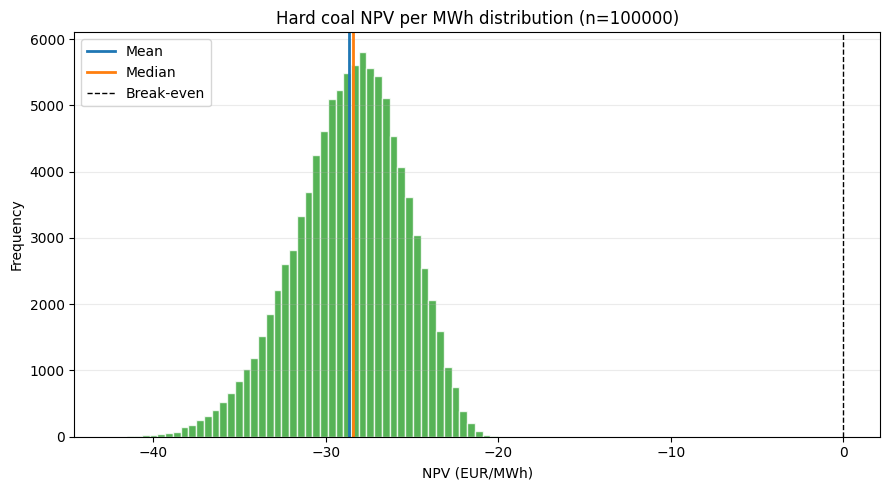

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    npv_eur_per_mwh,
    bins=50,
    color="tab:green",
    edgecolor="white",
    alpha=0.8,
)
ax.axvline(
    npv_eur_per_mwh.mean(),
    color="tab:blue",
    linewidth=2,
    label="Mean",
)
ax.axvline(
    npv_eur_per_mwh.median(),
    color="tab:orange",
    linewidth=2,
    label="Median",
)
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"Hard coal NPV per MWh distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("NPV (EUR/MWh)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()


In [6]:
annual_components = results[
    [
        "annual_revenue_eur",
        "annual_fixed_opex_eur",
        "annual_variable_opex_eur",
        "annual_fuel_cost_eur",
        "annual_emissions_cost_eur",
        "annual_net_cash_flow_eur",
    ]
] / 1_000_000

annual_components.mean().rename("Mean annual value, million EUR")

annual_revenue_eur           94.070000
annual_fixed_opex_eur         9.323888
annual_variable_opex_eur      5.167443
annual_fuel_cost_eur         31.071014
annual_emissions_cost_eur    69.856324
annual_net_cash_flow_eur    -21.348669
Name: Mean annual value, million EUR, dtype: float64